# Folder/file structure
`data/[speaker]/[number]_[speaker]_[repeats].wav`


## Play random file

In [8]:
import librosa
import IPython.display as ipd
import os
import random
import matplotlib.pyplot as plt
import soundfile as sf

mainpath = 'D:\\codethings\\GADy\\AudioMINST\\data'
testdir = 'D:\\codethings\\GADy\\AudioMINST\\Test'

# We got 60 speakers here
randomized_speaker = str(random.randint(1,60))
if int(randomized_speaker) < 10:
    randomized_speaker = '0' + str(randomized_speaker)

# Digits
random_digit = random.randint(0,9)

# Each number is repeated 50 times
repeat_num = random.randint(0,49)
                            
# Concat, get random audio file
random_file = mainpath + '\\' + str(randomized_speaker) + '\\' + str(random_digit) + '_' + str(randomized_speaker) + '_' + str(repeat_num) + '.wav'

print(random_file)
print(f'Path exists? : {os.path.exists(random_file)}' + '\n')

audio_data, sr = librosa.load(random_file, sr = 16000)

print(sf.info(random_file))
print('\n')

ipd.Audio(random_file)

D:\codethings\GADy\AudioMINST\data\03\6_03_28.wav
Path exists? : True

D:\codethings\GADy\AudioMINST\data\03\6_03_28.wav
samplerate: 48000 Hz
channels: 1
duration: 31022 samples
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]




## Plot comparison between 16kHz vs default librosa 22050 Hz

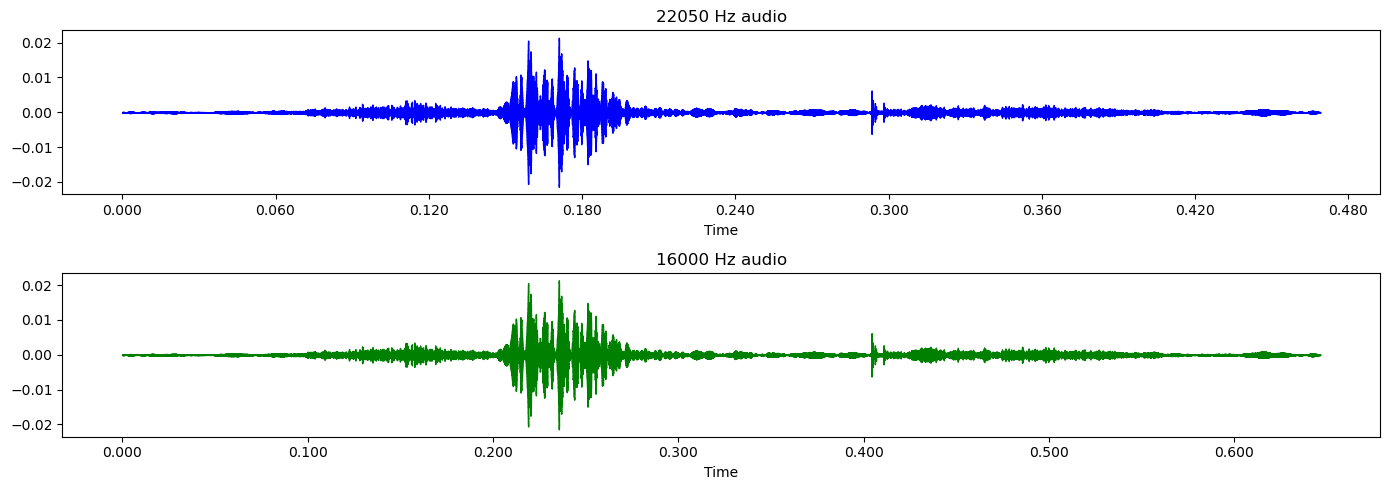

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(2, 1, 1)
librosa.display.waveshow(audio_data, sr=22050, color='blue')
plt.title('22050 Hz audio')

plt.subplot(2, 1, 2)
librosa.display.waveshow(audio_data, sr=16000, color='green')
plt.title('16000 Hz audio')

plt.tight_layout()

### Różnice w długościach próbek - to nie jest resample, to plt tak interpretuje "sr = ..." 
#### Aby sprawdzić jaki sr ma plik, używamy soundfile.

### Pora na spectrogramy

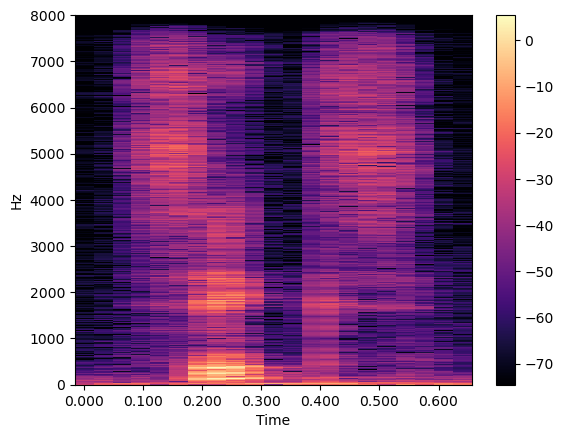

In [10]:
amplitude = librosa.stft(audio_data)
decibels = librosa.amplitude_to_db(abs(amplitude))

librosa.display.specshow(
    decibels, 
    sr=sr, 
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()

# Testowanie noisereduce (default)

D:\codethings\GADy\AudioMINST\Test\test.wav


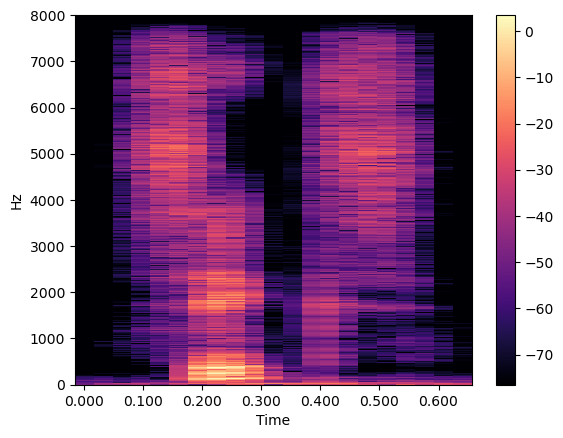

In [11]:
import noisereduce as nr

# Clear noise
reduced_noise = nr.reduce_noise(audio_data, sr)

# Save the file
dir_var = testdir + '\\' + 'test.wav'
print(dir_var)
sf.write(dir_var, reduced_noise, sr)

# Plot the spectrogram
reduced_amp = librosa.stft(reduced_noise)
reduced_db = librosa.amplitude_to_db(abs(reduced_amp))

librosa.display.specshow(
    reduced_db,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()

In [12]:
ipd.Audio(dir_var)

# Testowanie noisereduce (z samplem szumu)

In [13]:
sample_qty = int(sr * 60 / 1000)
noise = audio_data[:sample_qty]
reduced_noise = nr.reduce_noise(audio_data, sr=sr, y_noise=noise)
noisereduce_wsample = testdir + '\\' + 'noisereduce_wsample.wav'
sf.write(noisereduce_wsample, reduced_noise, sr)

ipd.Audio(noisereduce_wsample)

# Testowanie scipy.signal.wiener()

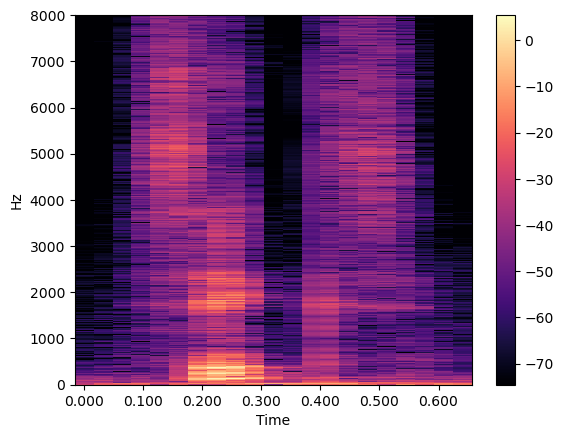

In [14]:
import scipy
filtered = scipy.signal.wiener(audio_data)
wiener_testing = dir_var = testdir + '\\' + 'wiener.wav'

sf.write(wiener_testing, filtered, sr)

amp_wiener = librosa.stft(filtered)
db_wiener = librosa.amplitude_to_db(abs(amp_wiener))
librosa.display.specshow(
    db_wiener,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()

In [15]:
ipd.Audio(wiener_testing)

## Sprawdzanie spektrogramu
### resample->wiener

In [16]:
# print(random_file.split('\\')[-1])
resampled_denoised_filename = 'wiener_rd_' + random_file.split('\\')[-1]
print(resampled_denoised_filename)
wiener_test= testdir + '\\' + resampled_denoised_filename

resample_wiener = librosa.resample(y=audio_data, target_sr=16000, orig_sr=sr)
test_wiener = scipy.signal.wiener(resample_wiener)
sf.write(wiener_test, test_wiener, 16000)
ipd.Audio(wiener_test)

wiener_rd_6_03_28.wav


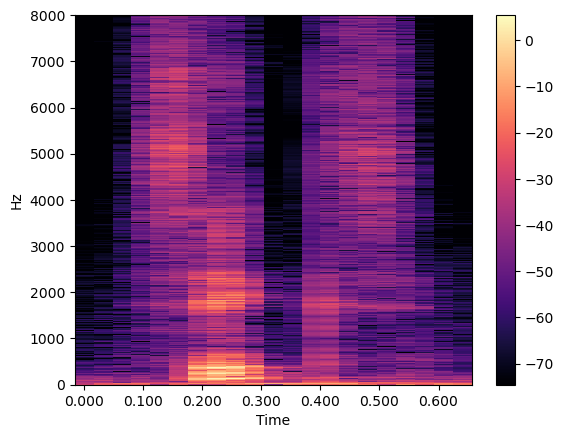

In [17]:
amp_test = librosa.stft(test_wiener)
db_test = librosa.amplitude_to_db(abs(amp_test))
librosa.display.specshow(
    db_test,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()

## Sprawdzanie spektrogramu
### resample->noisereduce

In [18]:
test_noisereduce = 'nr_rd_' + random_file.split('\\')[-1]
noisereduce_path = testdir + '\\' + test_noisereduce


resample_noisereduce = librosa.resample(y=audio_data, target_sr=16000, orig_sr=sr)
clean_noisereduce = nr.reduce_noise(resample_noisereduce, sr=16000)
sf.write(noisereduce_path, clean_noisereduce, 16000)
print(noisereduce_path)
ipd.Audio(noisereduce_path)

D:\codethings\GADy\AudioMINST\Test\nr_rd_6_03_28.wav


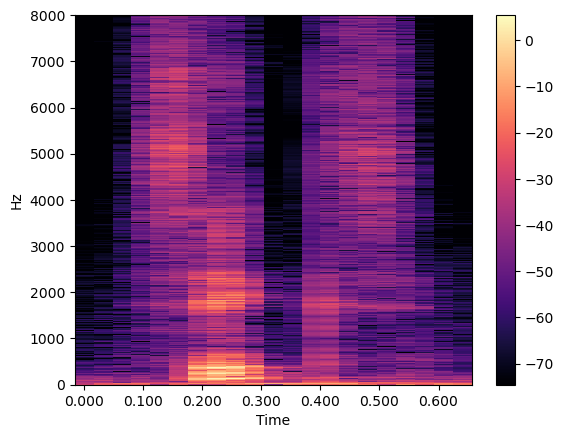

In [19]:
amp_nr = librosa.stft(clean_noisereduce)
db_nr = librosa.amplitude_to_db(abs(clean_noisereduce))
librosa.display.specshow(
    db_test,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()